<h1><strong>How Inflow with Ram Pressure Stripping responds to change of parameters</strong></h1>

In [1]:
import numpy as np
from   scipy.special import hyp2f1, expi
import matplotlib.pyplot as plt
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib.ticker import FormatStrFormatter
import irps

<h2><strong>1. Prepare some local functions </strong></h2>
<hr>
<table>
    <thead>
        <tr><th>Function</th><th>Arguments</th><th>Output</th><th>Description</th></tr>
    </thead>
    <tbody><tr><td>format_ticks</td>
        <td>
            <ul> 
                <li><em>majorl</em></li>
                <li><em>minorl</em></li> 
                <li><em>xdel</em></li>
                <li><em>ydel</em></li> 
            </ul>
        </td>
        <td>--</td>
        <td>Update tcks for <code>pyplot</code></td></tr>
    </tbody>
</table>

In [2]:
def format_ticks(majorl=15, minorl=7, xdel=1, ydel=5):
    '''
    This function is for figure formatting
    '''
    plt.rcParams.update({'font.family': 'DeJavu Serif'})
    plt.rcParams.update({'font.serif':'Times New Roman'})
    plt.gca().tick_params(which='major', direction="in", length=majorl,\
                        labelbottom=True, labeltop=False, labelleft=True, labelright=False,
                        bottom=True, top=True, left=True, right=True)
    plt.gca().tick_params(which='minor', direction="in", length=minorl,\
                        labelbottom=True, labeltop=False, labelleft=True, labelright=False,
    bottom=True, top=True, left=True, right=True)
    plt.gca().xaxis.set_major_locator(MultipleLocator(xdel))
    plt.gca().yaxis.set_major_locator(MultipleLocator(ydel))
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator(5))
    plt.gca().yaxis.set_minor_locator(AutoMinorLocator(5))

<h2><strong>3. Figures.</strong></h2>

TypeError: gas_equation() got multiple values for argument 'points'

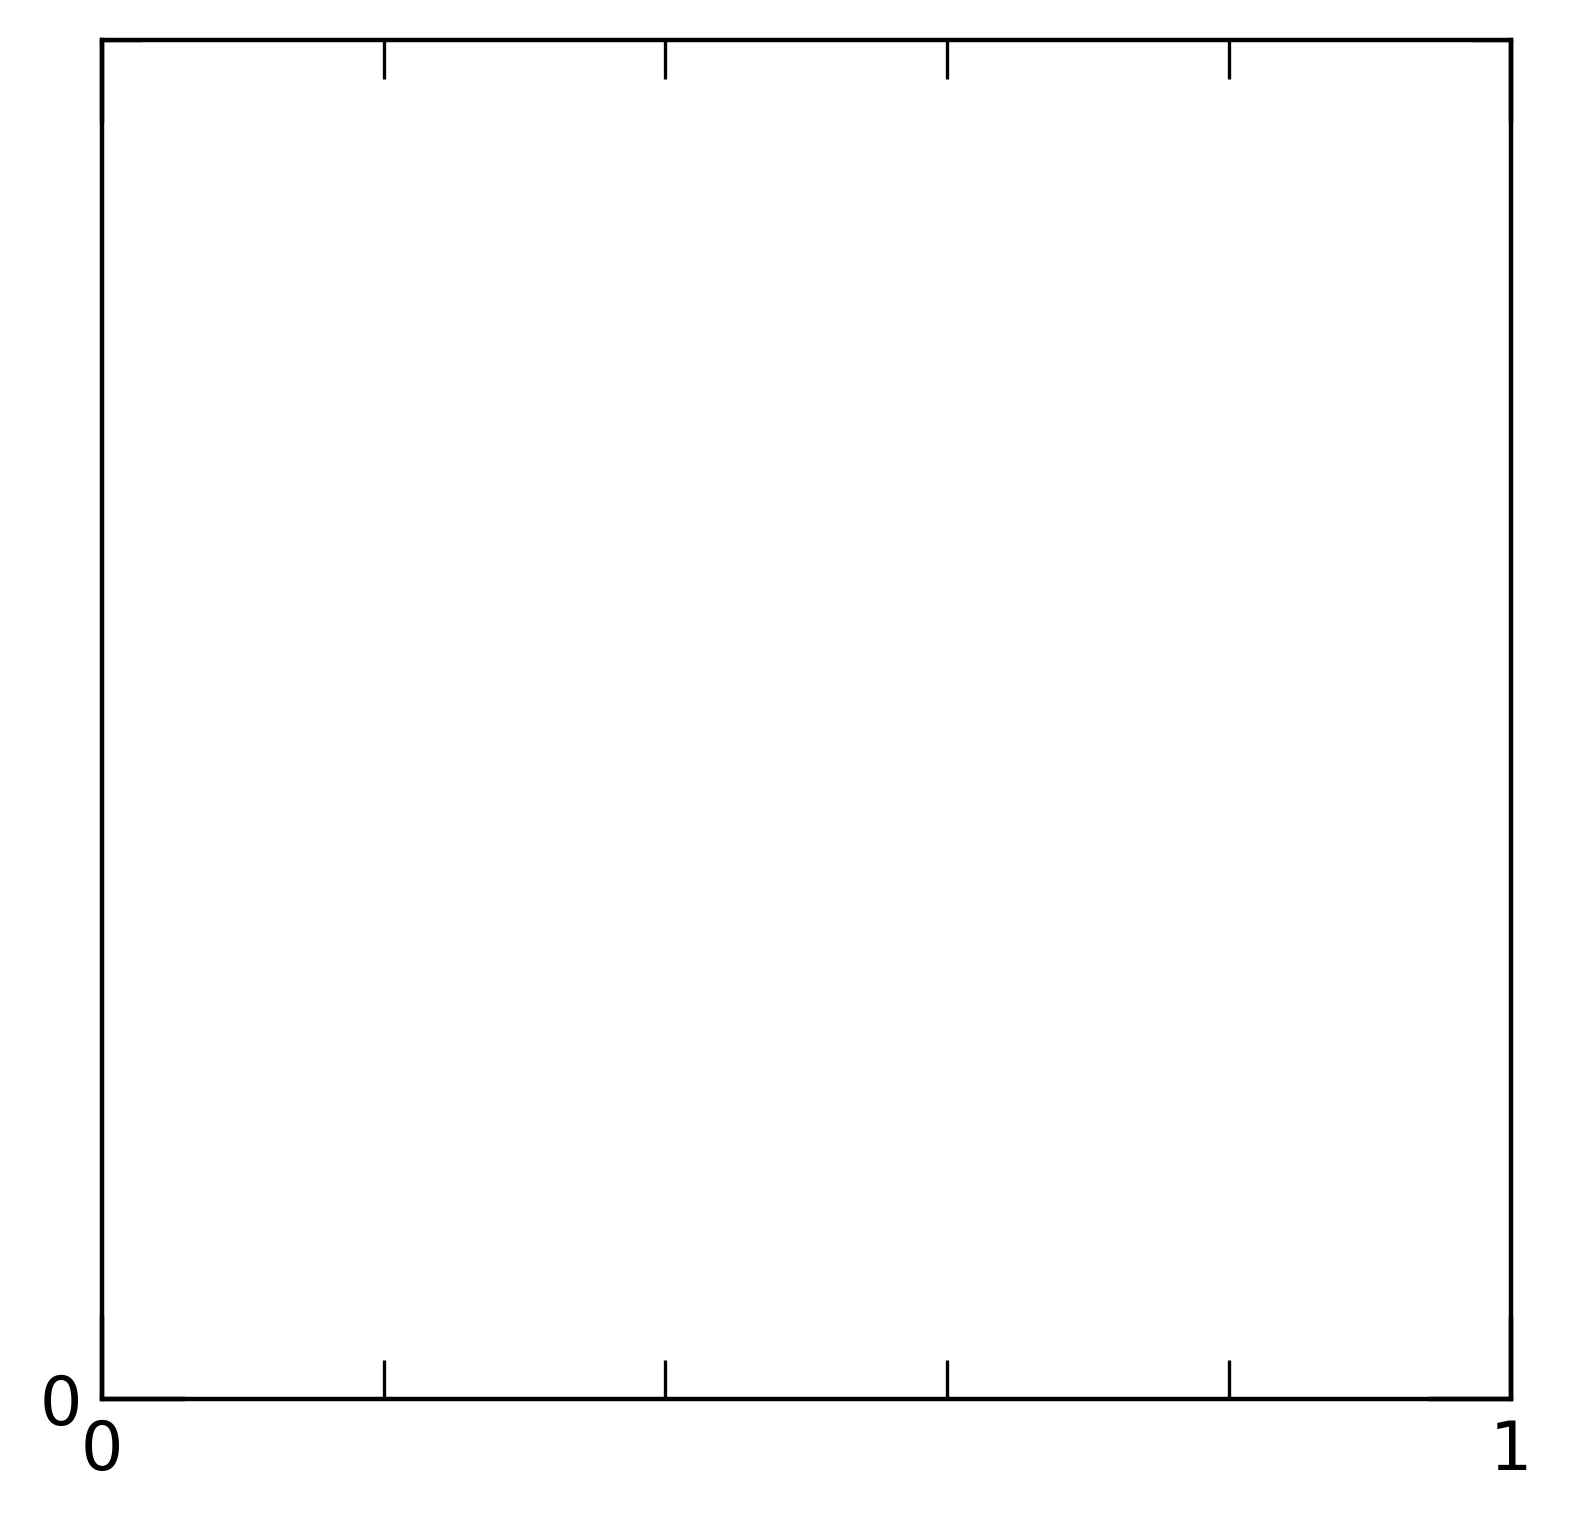

In [3]:
alphah = np.linspace(-5., 0., 5001)
p = 0.0222; F = 30; E = 2; aH_str = -1.9

fig  = plt.figure(figsize=(10,15), dpi=400)
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=9)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE-4)  # fontsize of the figure title

ax1 = fig.add_subplot(323)
format_ticks()
for index, temp in enumerate(np.linspace(5., 30, 5)):
    if index==4: labels = [False, False, True, [True, False, False, False, False]]
    else: labels = [False, False, False, [True, False, False, False, False]]
    gas2 = irps.gas_equation(p, temp, E, aH_str, 0.01, -5, -5, points=5001, ax=ax1,\
                        show=True, labels=labels, xx=-1.7);


ax2 = fig.add_subplot(324)
format_ticks()
for index, temp in enumerate(np.array([0.1, 7., 23., 50., 180.])):
    if index == 4: labels = [False, False, True, [False, True, False, False, False]]
    else: labels = [False, False, False, [False, True, False, False, False]]
    gas2 = irps.gas_equation(p, F, temp, aH_str, 0.01, -5, -5, points=5001, ax=ax2,\
                        show=True, labels=labels, xx=aH_str+(1/temp*(0.009 if temp==0.1 else 1.))**(0.5 if temp>25 else .4));

ax3 = fig.add_subplot(325)
format_ticks()
for index, temp in enumerate(np.array([0.02, 0.04, 0.06, 0.09, 0.12])):
    if index == 4: labels = [False, False, True, [False, False, True, False, False]]
    else: labels = [False, False, False, [False, False, True, False, False]]
    gas2 = irps.gas_equation(temp, F, E, aH_str, 0.01, -5, -5, points=5001, ax=ax3,\
                        show=True, labels=labels, xx=aH_str+(temp)**(0.5)/1.5);

ax4 = fig.add_subplot(326)
format_ticks()
for index, temp in enumerate(np.linspace(-3., -1.8, 5)):
    if index == 4: labels = [False, False, True, [False, False, False, True, False]]
    else: labels = [False, False, False, [False, False, False, True, False]]
    gas2 = irps.gas_equation(p, F, E, temp, 0.01, -5, -5, points=5001, ax=ax4,\
                        show=True, labels=labels, xx=temp+(abs(temp)/4.)**3);

ax5 = fig.add_subplot(321)
format_ticks()
#F = 25.1; E = 32.5; aH_str = -2.5
#for index, temp in enumerate(np.linspace(10.01, 28, 5)):
F = 30; E = 20.; aH_str = -1.9
for index, temp in enumerate([0.1, 5., 8., 13., 17.25]):
    if index==4: labels =  [True, True, True, [False, False, False, False, True]]
    else: labels = [False, False, False, [False, False, False, False, True]]
    gas2 = irps.gas_equation(p, F, E, aH_str, temp, -5, -5, points=5001, ax=ax5,\
                        show=True, labels=labels, xx = aH_str-0.1/temp)

ax5.legend(bbox_to_anchor=(1.04, 1), loc="upper left");
for ax in [ax5, ax1, ax2]:
    ax.set_xticklabels([])
    ax.set_xlabel(None)
for ax in [ax2, ax4]:
    ax.set_yticklabels([])
    ax.set_ylabel(None)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)
#plt.savefig(f'examples_sq_v2.eps', format='eps', bbox_inches='tight', pad_inches=0)
#plt.savefig(f'examples_sq_v2.pdf', format='eps', bbox_inches='tight', pad_inches=0)
plt.show()

## 

In [4]:
SMALL_SIZE = 14
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=10)
plt.rc('axes', titlesize=10)
plt.rc('axes', labelsize=MEDIUM_SIZE)
plt.rc('xtick', labelsize=SMALL_SIZE)
plt.rc('ytick', labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=14)
plt.rc('figure', titlesize=10)

#cs = ['deeppink', 'dodgerblue', 'yellow', 'darkorange', 'red']
cs = ['dodgerblue', 'royalblue', 'mediumblue', 'blue', 'navy']
#cs = ['mediumvioletred','darkmagenta','purple', 'indigo', 'midnightblue']
fig  = plt.figure(figsize=(20,8), dpi=1500)

ax = list(np.full((2,5), None))

alphah = np.linspace(-5., 0., 501)
p = 0.0222; F = 30; E = 2; aH_str = -1.9
parset = {'F': (np.linspace(5., 30, 5), np.full(5,-2.15), r'$\xi$'),\
          'Es': (np.array([0.1, 7., 23., 50., 180.]), np.array([aH_str+(1/temp*(0.009 if temp==0.1 else 1.))**(0.5 if temp>25 else .4) 
                                                        for temp in [0.1, 7., 23., 50., 180.]]), r'$\zeta$'),\
          'p_eff': (np.array([0.02, 0.04, 0.06, 0.09, 0.12]), aH_str - np.array([0.02*6., 0.04*6, 0.06*6, 0.12, 0.12*2.5]),\
                    r'$p_{eff}$'),\
          'aH_str': (np.linspace(-3., -1.8, 5), np.array([temp+(abs(temp)/4.)**3 
                                                        for temp in np.linspace(-3., -1.8, 5)]), r'$[\alpha/H]_{s}$'),\
          'F2': ([0.1, 5., 8., 13., 17.25], np.array([aH_str-0.1/temp for temp in [0.1, 5., 8., 13., 17.25]]), r'$\xi_{rps}$')}

for index0, key in enumerate(list(parset.keys())):
    
    ax[0][index0] = None
    ax[0][index0] = fig.add_subplot(2, 5, index0+1)
    format_ticks(15, 7, 0.5, 5)
    
    ax[1][index0] = None
    ax[1][index0] = fig.add_subplot(2, 5, index0+6)
    format_ticks(15, 7, 0.5, 0.5)
    
    for index1, temp in enumerate(parset[key][0]):
        labels = [False, False, False, [False, False, False, False, False]]
        
        if index1==4: labels[2] = False#True
        else:         labels[2] = False

        labels[3][index0] = True

        if key=='F2' and index1==4: labels[0] = labels[1] = labels[2] = True

        if key=='F':         p_eff, F, Es, aH_str, F2 = 0.0222, temp, 20,    -1.9, 0.01
        elif key=='Es':      p_eff, F, Es, aH_str, F2 = 0.0222, 30,   temp, -1.9, 0.01
        elif key=='p_eff':   p_eff, F, Es, aH_str, F2 = temp,   30,   20,    -1.9, 0.01
        elif key=='aH_str':  p_eff, F, Es, aH_str, F2 = 0.0222, 30,   20,    temp, 0.01
        elif key=='F2':      p_eff, F, Es, aH_str, F2 = 0.0222, 30,   20,   -1.9, temp
        
        gas2 = irps.gas_equation(p_eff, F, Es, aH_str, F2, -5., -5., points=501, ax=ax[0][index0],\
                            show=True, labels=labels, xx=parset[key][1][index1], c=cs[index1]);
        adf = irps.a2(p_eff, F, Es, aH_str, F2, alphah, gas2,  aH_f = -5.,\
                 show=True, ax=ax[1][index0], error=0.075, c=cs[index1], label= None if ((index0 != 4) or (index1 !=4)) else  \
                r"$[\alpha/H]$ distribution"+"\nfunction, convolved with\n gauss kernel\n"+r"$\sigma[\alpha/H]=0.075$")

    ax[1][index0].set_xlabel(r"$[\alpha/H]$")    
    if index0+6 == 6:
        ax[0][index0].set_ylabel("Gas, "+r'$M_{initial}$')
        ax[1][index0].set_ylabel("ADF, "+r"$\sigma [\alpha/H] = 0.075$")
    else:
        ax[0][index0].set_yticklabels([])
        ax[0][index0].set_ylabel(None)
        ax[1][index0].set_yticklabels([])
        ax[1][index0].set_ylabel(None)

    ax[0][index0].set_xticklabels([])
    ax[0][index0].set_xlabel(None)
    ax[0][index0].set_xlim([-3.6, -1.00001])
    
    ax[1][index0].set_ylim([-0.1, 3.])
    ax[1][index0].set_xlim([-3.6, -1.00001])

ax[0][4].legend(bbox_to_anchor=(1.04, 1), loc="upper left");
ax[1][4].legend(bbox_to_anchor=(1.04, 1), loc="upper left");

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0, hspace=0)
plt.savefig(f'examples_sq_v3.eps', format='eps', bbox_inches='tight', pad_inches=0)
plt.savefig(f'examples_sq_v3.png', format='png', bbox_inches='tight', pad_inches=0)
plt.show()

TypeError: gas_equation() got multiple values for argument 'points'